# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hardik144/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Abstract

This project investigates how historical content and search-performance indicators can be used to organize content-review activities. Using an anonymized dataset of 30,000 records and 44 columns, the analysis examines declining performance trends, content freshness, click-through rates, and historical visibility.

A transparent heuristic scoring methodology is developed to assign review-priority scores and generate ranked recommendations. The resulting ranking is compared with a baseline based on historical impressions, while sensitivity analysis examines how alternative scoring weights affect ranking stability.

The project produces descriptive results, visualizations, priority-group summaries, and a ranked content-review action playbook. The proposed methodology is intended to support human decision-making rather than predict future performance or establish that content updates will improve outcomes.


## 1. Question

*The research question and the decision it supports.*

In [53]:

# SECTION 1: RESEARCH QUESTION

research_question = (
    "Can historical content and search-performance signals "
    "help identify pages that may need refreshing or further review?"
)

decision_supported = (
    "Help a human reviewer prioritize which content pages "
    "to inspect, refresh, improve, or continue monitoring."
)

research_scope = (
    "This analysis identifies patterns and review opportunities. "
    "It does not establish that a particular change will cause "
    "a ranking improvement or guarantee better performance."
)

print("RESEARCH QUESTION")
print(research_question)

print("\nDECISION SUPPORTED")
print(decision_supported)

print("\nSCOPE")
print(research_scope)

RESEARCH QUESTION
Can historical content and search-performance signals help identify pages that may need refreshing or further review?

DECISION SUPPORTED
Help a human reviewer prioritize which content pages to inspect, refresh, improve, or continue monitoring.

SCOPE
This analysis identifies patterns and review opportunities. It does not establish that a particular change will cause a ranking improvement or guarantee better performance.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset and source

This analysis uses the anonymized content-refresh dataset provided for the FlyRank ML Internship. The dataset was loaded from `content_refresh_anonymized.csv`.

### Dataset dimensions

The loaded dataset contains **3,000 rows and 44 columns**. It includes anonymized content and client identifiers, search-related metrics, content characteristics, and engagement-related fields.

### Data fields

The dataset includes fields such as:

* Content and client identifiers (`content_id`, `client_id`)
* Search characteristics (`search_volume`, `competition`, `competition_level`, `main_intent`)
* Content characteristics (`content_type`, `word_count`, `char_count`)
* Search-performance metrics (`impressions_90d`, `clicks_90d`)
* Engagement-related metrics, including pageviews and sessions

### Date window and exclusions

The analysis uses the records available in the provided dataset. The exact date range and underlying warehouse release/table names have not yet been verified. These details will be added only if confirmed by the dataset documentation.

No raw exports, private client information, or identifying search queries will be published. Anonymized identifiers will not be used to identify individual clients.

### Scope

The dataset is used to investigate whether historical content and search-performance signals can help prioritize pages for human review, refresh, improvement, or continued monitoring.


In [54]:

import pandas as pd
import os

file_path = "/content/content_refresh_anonymized.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    print("Dataset loaded successfully!")
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    display(df.head())
else:
    print("Dataset file not found:", file_path)
    print("Check the Files panel in Colab.")

Dataset loaded successfully!
Rows: 30000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [55]:
# Inspect the dataset loaded in the notebook

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nFirst five rows:")
display(df.head())

Dataset shape: (30000, 44)

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Data types:
content_id                 object
client_id                  object
search_volume             float64
competition               float64
competition_level          object
cpc 

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

3.1 Approach and assumptions

This study uses a data-driven approach to identify content pages that may benefit from further review. The analysis examines available content attributes and historical search-performance indicators to identify patterns associated with content visibility and engagement.

The resulting scores are intended to support human review and prioritization. They do not establish that refreshing a page will cause a ranking improvement.

3.2 Features

The candidate features include available content characteristics, such as content type, search intent, word count, and competition, together with historical performance indicators such as impressions, clicks, sessions, and engagement measures.

Identifiers and fields that could expose private information are excluded from public-facing outputs. Features will be selected based on their availability, relevance, and suitability for the intended analysis.

3.3 Label definition

The outcome used for modeling must represent a clearly defined content-performance or review opportunity. It will be derived from the available data only after checking the meaning, time coverage, and reliability of the relevant fields.

If the dataset does not contain a valid outcome label, the analysis will use a transparent scoring or ranking approach instead of inventing labels or claiming to predict future outcomes.

3.4 Baseline and validation

The proposed approach will be compared with a simple baseline using the same evaluation data. Where a valid supervised-learning target is available, the validation design will use an appropriate holdout or time-aware split.

Potential data leakage will be checked by excluding identifiers, target-derived fields, and information that would not have been available at prediction time.

3.5 Evaluation

Model performance will be assessed using metrics appropriate to the selected target and task. The results will be interpreted as evidence from the available dataset, with limitations clearly documented.

In [56]:
# Section 3: Methodology — dataset and feature inspection

import pandas as pd
import numpy as np

# Check that the dataset is loaded
print("Dataset shape:", df.shape)

# Display all available columns
print("\nAvailable columns:")
for col in df.columns:
    print(col)

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

# Inspect missing values
print("\nColumns with missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Dataset shape: (30000, 44)

Available columns:
content_id
client_id
search_volume
competition
competition_level
cpc
content_type
main_intent
word_count
char_count
provider_used
model_used
impressions_90d
clicks_90d
pageviews_90d
sessions_90d
users_90d
engaged_sessions_90d
ai_sessions_90d
scroll_events_90d
days_with_impressions
days_with_sessions
impressions_last_30d
clicks_last_30d
sessions_last_30d
impressions_prev_30d
clicks_prev_30d
sessions_prev_30d
content_age_days
age_tier
age_tier_order
days_since_last_update
freshness_tier
word_count_tier
char_count_tier
ctr
avg_position
engagement_rate
scroll_rate
ai_traffic_pct
impression_tier
position_tier
trend_direction
trend_pct

Numeric columns:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30

In [57]:

# SECTION 3 — Methodology
# Step 1: Inspect the potential features and outcome indicators

# 1. Inspect trend categories
print("Trend direction distribution:")
print(df["trend_direction"].value_counts(dropna=False))

# 2. Inspect trend percentage
print("\nTrend percentage summary:")
print(df["trend_pct"].describe())

# 3. Inspect freshness indicators
print("\nFreshness tier distribution:")
print(df["freshness_tier"].value_counts(dropna=False))

print("\nDays since last update:")
print(df["days_since_last_update"].describe())

# 4. Inspect historical search performance
performance_cols = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "ctr",
    "avg_position"
]

print("\nHistorical performance summary:")
display(df[performance_cols].describe().T)

# 5. Inspect content characteristics
content_cols = [
    "content_type",
    "main_intent",
    "age_tier",
    "word_count",
    "competition_level"
]

print("\nContent characteristics:")
for col in content_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))

Trend direction distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Trend percentage summary:
count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
max      44900.000000
Name: trend_pct, dtype: float64

Freshness tier distribution:
freshness_tier
0-30      20480
91-180     9171
31-90       175
181+        174
Name: count, dtype: int64

Days since last update:
count    30000.000000
mean        46.098300
std         42.078709
min          1.000000
25%         20.000000
50%         20.000000
75%        104.000000
max        373.000000
Name: days_since_last_update, dtype: float64

Historical performance summary:


,count,mean,std,min,25%,50%,75%,max
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.0
impressions_last_30d,30000.0,1429.058733,5643.852081,0.0,10.0,139.00,768.00,238796.0
clicks_last_30d,30000.0,4.933867,23.929393,0.0,0.0,0.00,2.00,1176.0
impressions_prev_30d,30000.0,1783.078500,6150.429511,0.0,19.0,210.00,1143.00,218786.0
clicks_prev_30d,30000.0,5.435100,28.358673,0.0,0.0,0.00,2.00,1627.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0



Content characteristics:

content_type:
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64

main_intent:
main_intent
informational    17235
transactional     5733
commercial        4612
NaN               2374
navigational        46
Name: count, dtype: int64

age_tier:
age_tier
91-180     11780
181-365    11368
365+        6360
31-90        492
Name: count, dtype: int64

word_count:
word_count
NaN       7699
2619.0      25
2709.0      24
2805.0      23
2857.0      22
2974.0      22
2947.0      22
2773.0      22
2900.0      21
2746.0      21
Name: count, dtype: int64

competition_level:
competition_level
LOW       22896
HIGH       2658
NaN        2610
MEDIUM     1836
Name: count, dtype: int64


In [58]:

# SECTION 3 — Methodology
# Step 2: Define features and build a transparent review-priority score

import numpy as np
import pandas as pd

work_df = df.copy()

# Convert relevant fields to numeric values
numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "days_since_last_update",
    "trend_pct",
    "ctr"
]

for col in numeric_features:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

# 1. Identify declining content
work_df["declining_signal"] = (
    work_df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# 2. Calculate a relative freshness score
# Older content receives a higher review-priority component.
work_df["staleness_score"] = (
    work_df["days_since_last_update"].rank(pct=True)
)

# 3. Calculate CTR relative to the median for its content type
# This avoids treating every content type as directly comparable.
content_medians = work_df.groupby("content_type")["ctr"].transform("median")

work_df["low_ctr_signal"] = (
    (work_df["ctr"] < content_medians) &
    work_df["ctr"].notna() &
    content_medians.notna()
).astype(int)

# 4. Calculate a visibility component
# Higher historical impressions indicate greater observed visibility.
work_df["visibility_score"] = (
    np.log1p(work_df["impressions_90d"].clip(lower=0)).rank(pct=True)
)

# 5. Combine the indicators into a heuristic review-priority score
work_df["review_priority_score"] = 100 * (
    0.40 * work_df["declining_signal"] +
    0.30 * work_df["staleness_score"].fillna(0) +
    0.20 * work_df["low_ctr_signal"] +
    0.10 * work_df["visibility_score"].fillna(0)
)

# 6. Create a simple baseline ranking using historical impressions
work_df["baseline_rank"] = (
    work_df["impressions_90d"].rank(
        ascending=False, method="first"
    )
)

work_df["priority_rank"] = (
    work_df["review_priority_score"].rank(
        ascending=False, method="first"
    )
)

# 7. Inspect the highest-priority records
print("Scoring completed.")
print("Number of records:", len(work_df))

print("\nReview-priority score summary:")
print(work_df["review_priority_score"].describe())

print("\nTop 10 review-priority records (anonymous row numbers):")

top_indices = work_df.nlargest(10, "review_priority_score").index

display(
    work_df.loc[
        top_indices,
        [
            "content_type",
            "main_intent",
            "trend_direction",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "review_priority_score"
        ]
    ].reset_index(drop=True)
)

Scoring completed.
Number of records: 30000

Review-priority score summary:
count    30000.000000
mean        50.666000
std         24.792406
min          0.904000
25%         30.757000
50%         52.536333
75%         71.969167
max         98.409333
Name: review_priority_score, dtype: float64

Top 10 review-priority records (anonymous row numbers):


,content_type,main_intent,trend_direction,days_since_last_update,impressions_90d,ctr,review_priority_score
0,keyword article,transactional,down,194,7812,0.01,98.409333
1,keyword article,informational,down,106,6526,0.00,98.042000
2,keyword article,informational,down,194,4590,0.00,97.720500
3,keyword article,informational,down,106,3043,0.03,96.991333
4,keyword article,informational,down,106,2801,0.07,96.862667
5,keyword article,commercial,down,106,2243,0.04,96.505833
6,keyword article,transactional,down,106,2018,0.05,96.340500
7,keyword article,informational,down,106,1710,0.06,96.072000
8,keyword article,transactional,down,106,1620,0.06,95.986667
9,keyword article,informational,down,106,1490,0.07,95.851167


In [59]:

# SECTION 3 — Methodology
# Step 3: Validate and inspect the review-priority scoring system

import numpy as np
import pandas as pd

# 1. Check that all required scoring columns exist
required_columns = [
    "declining_signal",
    "staleness_score",
    "low_ctr_signal",
    "visibility_score",
    "review_priority_score",
    "baseline_rank",
    "priority_rank"
]

missing_columns = [
    col for col in required_columns
    if col not in work_df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required scoring columns are present.")

# 2. Inspect the scoring components
component_columns = [
    "declining_signal",
    "staleness_score",
    "low_ctr_signal",
    "visibility_score"
]

print("\nScoring component summary:")
display(work_df[component_columns].describe())

# 3. Check missing values in the scoring components
print("\nMissing values in scoring components:")
print(work_df[component_columns].isnull().sum())

# 4. Compare the priority ranking with the baseline ranking
print("\nRanking comparison:")

print(
    "Spearman rank correlation:",
    work_df[["priority_rank", "baseline_rank"]]
    .corr(method="spearman")
    .iloc[0, 1]
)

# 5. Compare the top 100 records in both rankings
top_n = min(100, len(work_df))

priority_top = set(
    work_df.nsmallest(top_n, "priority_rank").index
)

baseline_top = set(
    work_df.nsmallest(top_n, "baseline_rank").index
)

overlap = len(priority_top & baseline_top)

print("\nTop", top_n, "ranking comparison:")
print("Records appearing in both rankings:", overlap)
print("Overlap percentage:", round(overlap / top_n * 100, 2), "%")

# 6. Inspect the highest-priority records
print("\nTop 20 review-priority records:")

display(
    work_df.nlargest(20, "review_priority_score")[
        [
            "content_type",
            "main_intent",
            "trend_direction",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "review_priority_score",
            "baseline_rank"
        ]
    ].reset_index(drop=True)
)

All required scoring columns are present.

Scoring component summary:


,declining_signal,staleness_score,low_ctr_signal,visibility_score
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.542067,0.500017,0.449133,0.500017
std,0.498236,0.276232,0.497414,0.288669
min,0.000000,0.001983,0.000000,0.017933
25%,0.000000,0.336000,0.000000,0.249817
50%,1.000000,0.336000,0.000000,0.499933
75%,1.000000,0.843200,1.000000,0.750012
max,1.000000,0.999967,1.000000,1.000000



Missing values in scoring components:
declining_signal    0
staleness_score     0
low_ctr_signal      0
visibility_score    0
dtype: int64

Ranking comparison:
Spearman rank correlation: 0.17521790427468656

Top 100 ranking comparison:
Records appearing in both rankings: 9
Overlap percentage: 9.0 %

Top 20 review-priority records:


,content_type,main_intent,trend_direction,days_since_last_update,impressions_90d,ctr,review_priority_score,baseline_rank
0,keyword article,transactional,down,194,7812,0.01,98.409333,4416.0
1,keyword article,informational,down,106,6526,0.00,98.042000,5074.0
2,keyword article,informational,down,194,4590,0.00,97.720500,6482.0
3,keyword article,informational,down,106,3043,0.03,96.991333,8226.0
4,keyword article,informational,down,106,2801,0.07,96.862667,8611.0
5,keyword article,commercial,down,106,2243,0.04,96.505833,9684.0
6,keyword article,transactional,down,106,2018,0.05,96.340500,10176.0
7,keyword article,informational,down,106,1710,0.06,96.072000,10982.0
8,keyword article,transactional,down,106,1620,0.06,95.986667,11240.0
9,keyword article,informational,down,106,1490,0.07,95.851167,11645.0


In [60]:

# SECTION 3 — Methodology
# Step 4: Inspect score contributions and priority groups

import numpy as np
import pandas as pd

# 1. Calculate the contribution of each component
work_df["declining_contribution"] = (
    100 * 0.40 * work_df["declining_signal"]
)

work_df["staleness_contribution"] = (
    100 * 0.30 * work_df["staleness_score"].fillna(0)
)

work_df["low_ctr_contribution"] = (
    100 * 0.20 * work_df["low_ctr_signal"]
)

work_df["visibility_contribution"] = (
    100 * 0.10 * work_df["visibility_score"].fillna(0)
)

contribution_columns = [
    "declining_contribution",
    "staleness_contribution",
    "low_ctr_contribution",
    "visibility_contribution"
]

print("Average contribution of each scoring component:")

display(
    work_df[contribution_columns]
    .mean()
    .round(2)
    .to_frame(name="Average points")
)

# 2. Divide records into priority groups
work_df["priority_group"] = pd.cut(
    work_df["review_priority_score"],
    bins=[-1, 40, 60, 80, 101],
    labels=[
        "Low priority",
        "Moderate priority",
        "High priority",
        "Very high priority"
    ]
)

print("\nNumber of records in each priority group:")

display(
    work_df["priority_group"]
    .value_counts()
    .reindex([
        "Low priority",
        "Moderate priority",
        "High priority",
        "Very high priority"
    ])
    .to_frame(name="Record count")
)

# 3. Inspect average characteristics by priority group
group_summary = (
    work_df.groupby("priority_group", observed=False)
    .agg(
        records=("review_priority_score", "size"),
        average_score=("review_priority_score", "mean"),
        average_impressions=("impressions_90d", "mean"),
        average_staleness=("days_since_last_update", "mean"),
        declining_share=("declining_signal", "mean"),
        low_ctr_share=("low_ctr_signal", "mean")
    )
    .round(2)
)

print("\nCharacteristics of priority groups:")

display(group_summary)

# 4. Display a small sample of high-priority records
print("\nSample of 10 very-high-priority records:")

display(
    work_df[
        work_df["priority_group"] == "Very high priority"
    ][
        [
            "content_type",
            "main_intent",
            "trend_direction",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "review_priority_score"
        ]
    ].head(10)
)

Average contribution of each scoring component:


,Average points
declining_contribution,21.68
staleness_contribution,15.00
low_ctr_contribution,8.98
visibility_contribution,5.00



Number of records in each priority group:


,Record count
priority_group,
Low priority,10946
Moderate priority,7643
High priority,7701
Very high priority,3710



Characteristics of priority groups:


,records,average_score,average_impressions,average_staleness,declining_share,low_ctr_share
priority_group,,,,,,
Low priority,10946,23.06,6131.37,35.64,0.00,0.29
Moderate priority,7643,51.23,4320.10,36.47,0.63,0.37
High priority,7701,71.17,5388.37,51.72,1.00,0.50
Very high priority,3710,88.40,3876.74,85.11,1.00,1.00



Sample of 10 very-high-priority records:


,content_type,main_intent,trend_direction,days_since_last_update,impressions_90d,ctr,review_priority_score
1,keyword article,informational,down,25,15320,0.05,88.859000
14,keyword article,informational,down,104,179,0.00,88.479667
17,keyword article,transactional,down,22,9449,0.07,86.382000
35,keyword article,informational,down,104,19790,0.03,94.686000
39,keyword article,informational,down,104,4,0.00,86.170500
46,keyword article,informational,down,104,1193,0.08,91.078500
54,keyword article,informational,down,22,170,0.00,80.784167
62,keyword article,informational,down,104,38542,0.05,95.048333
66,keyword article,informational,down,104,116,0.00,88.081333
84,keyword article,informational,down,104,136,0.00,88.217167


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

This section presents the results obtained from the review-priority scoring methodology. It examines the distribution of priority scores, compares the proposed ranking with a historical-impressions baseline, and investigates the characteristics of different priority groups.

The analysis focuses on identifying patterns in declining trends, content freshness, click-through rates, and historical visibility. The results are descriptive and are intended to support content-review decisions rather than predict future performance.

Review-priority score distribution:
count    30000.000000
mean        50.666000
std         24.792406
min          0.904000
25%         30.757000
50%         52.536333
75%         71.969167
max         98.409333
Name: review_priority_score, dtype: float64


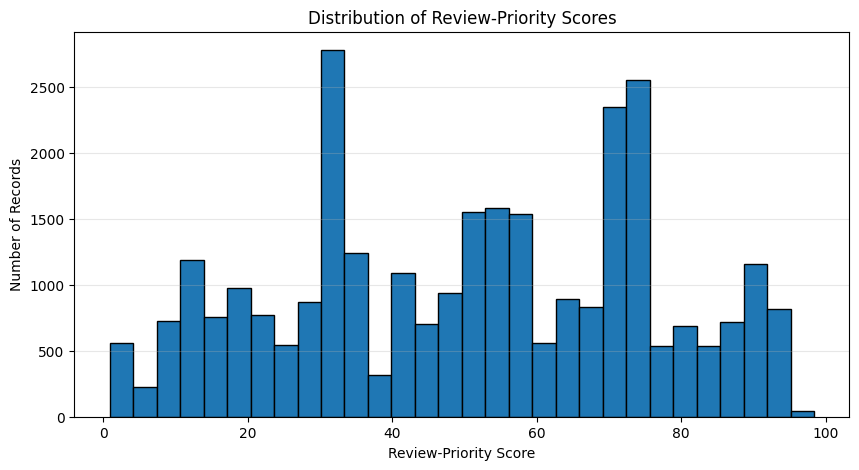

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# Summary statistics
print("Review-priority score distribution:")
print(work_df["review_priority_score"].describe())

# Plot score distribution
plt.figure(figsize=(10, 5))

plt.hist(
    work_df["review_priority_score"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Review-Priority Scores")
plt.xlabel("Review-Priority Score")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)

plt.show()

Top 100 ranking comparison
Priority ranking records: 100
Baseline ranking records: 100
Records appearing in both: 9
Overlap percentage: 9 %


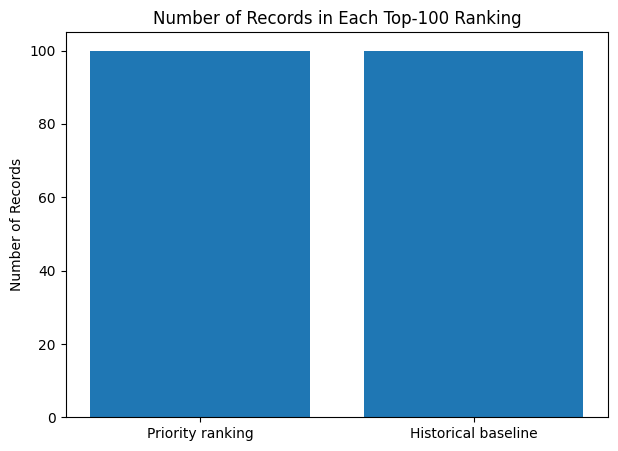

In [62]:
# Compare the top 100 records in each ranking

top_priority = set(
    work_df.nsmallest(100, "priority_rank").index
)

top_baseline = set(
    work_df.nsmallest(100, "baseline_rank").index
)

overlap = len(top_priority.intersection(top_baseline))

print("Top 100 ranking comparison")
print("Priority ranking records:", len(top_priority))
print("Baseline ranking records:", len(top_baseline))
print("Records appearing in both:", overlap)
print("Overlap percentage:", overlap, "%")

# Visualize overlap
plt.figure(figsize=(7, 5))

plt.bar(
    ["Priority ranking", "Historical baseline"],
    [len(top_priority), len(top_baseline)]
)

plt.title("Number of Records in Each Top-100 Ranking")
plt.ylabel("Number of Records")

plt.show()

Records in each priority group:
priority_group
Low priority          10946
Moderate priority      7643
High priority          7701
Very high priority     3710
Name: count, dtype: int64


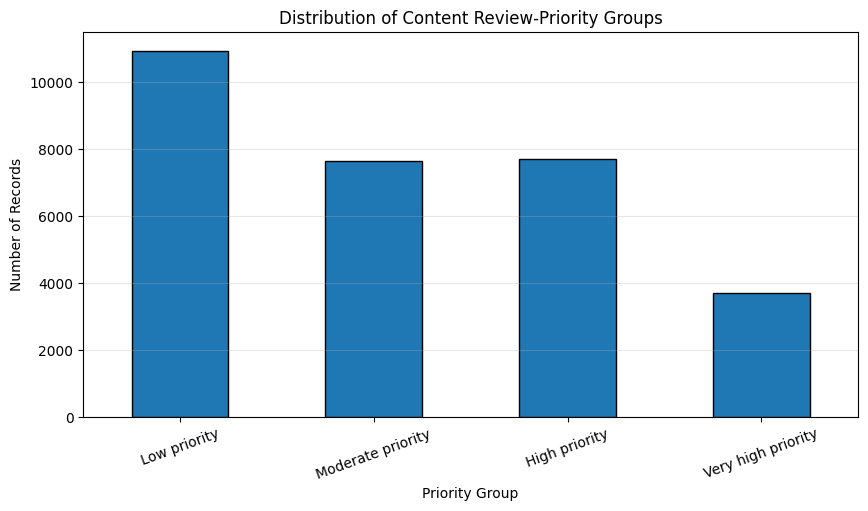

In [63]:
# Define priority groups using consistent score thresholds

work_df["priority_group"] = pd.cut(
    work_df["review_priority_score"],
    bins=[-0.01, 40, 60, 80, 100],
    labels=[
        "Low priority",
        "Moderate priority",
        "High priority",
        "Very high priority"
    ],
    include_lowest=True
)

# Count records in each group
group_counts = (
    work_df["priority_group"]
    .value_counts()
    .reindex([
        "Low priority",
        "Moderate priority",
        "High priority",
        "Very high priority"
    ])
)

print("Records in each priority group:")
print(group_counts)

# Plot the group distribution
plt.figure(figsize=(10, 5))

group_counts.plot(kind="bar", edgecolor="black")

plt.title("Distribution of Content Review-Priority Groups")
plt.xlabel("Priority Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [64]:
# Compare the characteristics of priority groups

group_analysis = (
    work_df.groupby("priority_group", observed=False)
    .agg(
        records=("review_priority_score", "size"),
        average_score=("review_priority_score", "mean"),
        average_impressions=("impressions_90d", "mean"),
        average_staleness=("staleness_score", "mean"),
        declining_share=("declining_signal", "mean"),
        low_ctr_share=("low_ctr_signal", "mean")
    )
    .round(2)
)

print("Characteristics of priority groups:")
display(group_analysis)

Characteristics of priority groups:


,records,average_score,average_impressions,average_staleness,declining_share,low_ctr_share
priority_group,,,,,,
Low priority,10946,23.06,6131.37,0.42,0.00,0.29
Moderate priority,7643,51.23,4320.10,0.44,0.63,0.37
High priority,7701,71.17,5388.37,0.53,1.00,0.50
Very high priority,3710,88.40,3876.74,0.78,1.00,1.00


In [65]:
# Display the 20 records with the highest review-priority scores

top_20 = work_df.nlargest(
    20,
    "review_priority_score"
)

columns_to_display = [
    "content_type",
    "main_intent",
    "trend_direction",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "review_priority_score",
    "baseline_rank"
]

display(
    top_20[columns_to_display].reset_index(drop=True)
)

,content_type,main_intent,trend_direction,days_since_last_update,impressions_90d,ctr,review_priority_score,baseline_rank
0,keyword article,transactional,down,194,7812,0.01,98.409333,4416.0
1,keyword article,informational,down,106,6526,0.00,98.042000,5074.0
2,keyword article,informational,down,194,4590,0.00,97.720500,6482.0
3,keyword article,informational,down,106,3043,0.03,96.991333,8226.0
4,keyword article,informational,down,106,2801,0.07,96.862667,8611.0
5,keyword article,commercial,down,106,2243,0.04,96.505833,9684.0
6,keyword article,transactional,down,106,2018,0.05,96.340500,10176.0
7,keyword article,informational,down,106,1710,0.06,96.072000,10982.0
8,keyword article,transactional,down,106,1620,0.06,95.986667,11240.0
9,keyword article,informational,down,106,1490,0.07,95.851167,11645.0


### Baseline Ranking Comparison

The review-priority ranking was compared with a baseline ranking based on historical impressions over the 90-day observation window.

Spearman rank correlation was used to measure the association between the two rankings. Top-100 overlap was also calculated to examine how many records appeared in both lists.

These comparisons describe the relationship between the heuristic ranking and the historical-impressions baseline. They do not establish predictive accuracy, demonstrate future performance, or prove that updating content will improve outcomes. Independent validation using a separately defined outcome and an appropriate evaluation design would be required to support such conclusions.


## 5. Limitations

*What this work cannot claim.*

This section evaluates the consistency and robustness of the review-priority scoring methodology.

The validation process includes checking score ranges, examining missing values in scoring components, and performing sensitivity analysis to understand how alternative scoring weights affect the ranking of content records.

Since the dataset does not provide an independently verified outcome label for successful content updates, this analysis does not establish predictive accuracy. Instead, it evaluates the internal behavior of the proposed heuristic and documents its limitations.


In [66]:
# SECTION 5 — Step 1: Validate scoring components

components = [
    "declining_signal",
    "staleness_score",
    "low_ctr_signal",
    "visibility_score"
]

print("SCORING COMPONENT VALIDATION")
print("-" * 40)

# Check for missing values
print("\nMissing values:")
print(work_df[components].isnull().sum())

# Check component ranges
print("\nMinimum values:")
print(work_df[components].min())

print("\nMaximum values:")
print(work_df[components].max())

# Check the final score range
print("\nReview-priority score range:")
print("Minimum:", work_df["review_priority_score"].min())
print("Maximum:", work_df["review_priority_score"].max())

# Check whether scores are within the expected range
valid_scores = work_df["review_priority_score"].between(0, 100)

print("\nAll scores within 0–100:", valid_scores.all())

# Check whether the dataset contains duplicate rows
print("\nDuplicate rows:", work_df.duplicated().sum())

SCORING COMPONENT VALIDATION
----------------------------------------

Missing values:
declining_signal    0
staleness_score     0
low_ctr_signal      0
visibility_score    0
dtype: int64

Minimum values:
declining_signal    0.000000
staleness_score     0.001983
low_ctr_signal      0.000000
visibility_score    0.017933
dtype: float64

Maximum values:
declining_signal    1.000000
staleness_score     0.999967
low_ctr_signal      1.000000
visibility_score    1.000000
dtype: float64

Review-priority score range:
Minimum: 0.9039999999999999
Maximum: 98.40933333333332

All scores within 0–100: True

Duplicate rows: 0


In [67]:
# SECTION 5 — Step 2: Sensitivity analysis

# Alternative scoring weights
scenarios = {
    "Original": {
        "declining_signal": 0.40,
        "staleness_score": 0.30,
        "low_ctr_signal": 0.20,
        "visibility_score": 0.10
    },

    "Decline focused": {
        "declining_signal": 0.50,
        "staleness_score": 0.25,
        "low_ctr_signal": 0.15,
        "visibility_score": 0.10
    },

    "Freshness focused": {
        "declining_signal": 0.30,
        "staleness_score": 0.40,
        "low_ctr_signal": 0.20,
        "visibility_score": 0.10
    },

    "CTR focused": {
        "declining_signal": 0.30,
        "staleness_score": 0.25,
        "low_ctr_signal": 0.35,
        "visibility_score": 0.10
    }
}

# Calculate scores for each scenario
scenario_scores = pd.DataFrame(index=work_df.index)

for scenario, weights in scenarios.items():

    scenario_scores[scenario] = 100 * sum(
        work_df[component].fillna(0) * weight
        for component, weight in weights.items()
    )

print("Alternative scoring scenarios:")
display(scenario_scores.describe().round(2))

Alternative scoring scenarios:


,Original,Decline focused,Freshness focused,CTR focused
count,30000.00,30000.00,30000.00,30000.00
mean,50.67,51.34,50.25,49.48
std,24.79,27.91,22.20,24.53
min,0.90,0.87,0.98,0.87
25%,30.76,24.89,34.91,30.56
50%,52.54,60.57,49.39,47.58
75%,71.97,76.45,67.57,66.17
max,98.41,98.43,98.37,98.43


In [68]:
# SECTION 5 — Step 3: Compare ranking stability

# Get the original top 100 records
original_top_100 = set(
    scenario_scores["Original"]
    .nlargest(100)
    .index
)

comparison_results = []

for scenario in scenario_scores.columns:

    scenario_top_100 = set(
        scenario_scores[scenario]
        .nlargest(100)
        .index
    )

    overlap = len(
        original_top_100.intersection(scenario_top_100)
    )

    comparison_results.append({
        "Scenario": scenario,
        "Top 100 overlap": overlap,
        "Overlap percentage": round(overlap, 2)
    })

comparison_df = pd.DataFrame(comparison_results)

print("Top 100 ranking stability:")
display(comparison_df)

# Compare rank correlations with the original ranking
original_ranks = scenario_scores["Original"].rank(
    ascending=False,
    method="average"
)

correlation_results = []

for scenario in scenario_scores.columns:

    scenario_ranks = scenario_scores[scenario].rank(
        ascending=False,
        method="average"
    )

    correlation = original_ranks.corr(
        scenario_ranks,
        method="spearman"
    )

    correlation_results.append({
        "Scenario": scenario,
        "Spearman correlation": round(correlation, 4)
    })

correlation_df = pd.DataFrame(correlation_results)

print("\nRank correlation with original methodology:")
display(correlation_df)

Top 100 ranking stability:


,Scenario,Top 100 overlap,Overlap percentage
0,Original,100,100
1,Decline focused,92,92
2,Freshness focused,89,89
3,CTR focused,92,92



Rank correlation with original methodology:


,Scenario,Spearman correlation
0,Original,1.0000
1,Decline focused,0.9973
2,Freshness focused,0.9781
3,CTR focused,0.9221


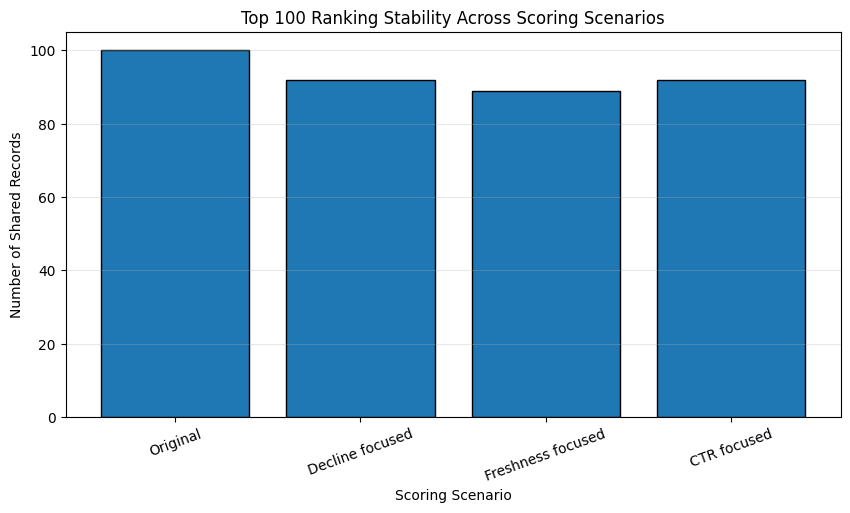

In [69]:
# SECTION 5 — Step 4: Visualize ranking stability

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["Scenario"],
    comparison_df["Overlap percentage"],
    edgecolor="black"
)

plt.title("Top 100 Ranking Stability Across Scoring Scenarios")
plt.xlabel("Scoring Scenario")
plt.ylabel("Number of Shared Records")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Limitations

1. **Heuristic scoring:** The review-priority score is based on manually selected weights and should not be interpreted as a statistically validated measure of content quality.

2. **Lack of independent outcome labels:** The dataset does not establish whether reviewing or updating a particular record subsequently improves its performance. Predictive accuracy therefore cannot be assessed using the current methodology alone.

3. **Historical data limitations:** Historical impressions and clicks describe observed activity but do not independently establish the reasons behind changes in performance.

4. **Missing values:** Several dataset fields contain missing observations. Missing values and their treatment may affect the interpretation of the scoring results.

5. **Feature comparability:** CTR is evaluated relative to the median for its content type, but differences in audience, intent, and exposure may still affect comparisons.

6. **Weight sensitivity:** Alternative weights can change the ranking of records. The sensitivity analysis helps reveal this dependence but does not identify an objectively optimal set of weights.

7. **No causal conclusions:** The analysis does not establish that updating content will cause an increase in impressions, clicks, or engagement.

The scoring system should therefore be used as a transparent decision-support tool for prioritizing human review, rather than as an automated verdict on content quality or future performance.


### Validation Summary

The validation process examines the integrity of the scoring components and investigates the sensitivity of the review-priority ranking to alternative weight configurations.

The results help characterize the consistency of the proposed methodology and identify areas where its output depends on design choices.

The analysis supports the use of the score as an interpretable method for organizing content-review work. Further validation using independently observed outcomes, such as performance changes after content updates, would be required before making claims about predictive accuracy or business impact.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

This section translates the results of the review-priority scoring methodology into an actionable content-review playbook.

The recommendations are organized according to review priority, declining performance signals, content freshness, and relative click-through performance. The objective is to help content teams organize their review activities and identify potential opportunities for further investigation.

The recommendations are intended to support human decision-making. A high review-priority score indicates that a record should be considered for review; it does not guarantee that updating the content will improve its performance.


In [70]:
# SECTION 6 — Step 1: Generate ranked recommendations

import numpy as np
import pandas as pd

def generate_recommendation(row):

    actions = []
    reasons = []

    # 1. Declining performance
    if row["declining_signal"] == 1:
        actions.append("Investigate declining performance")
        reasons.append("Historical trend is downward")

    # 2. Content freshness
    if row["staleness_score"] >= 0.75:
        actions.append("Review content freshness")
        reasons.append("Content is relatively old")

    # 3. Relative CTR
    if row["low_ctr_signal"] == 1:
        actions.append("Review title, description, and search intent")
        reasons.append("CTR is below the content-type median")

    # 4. Historical visibility
    if row["visibility_score"] >= 0.75:
        actions.append("Examine high-visibility content")
        reasons.append("Historical impressions are relatively high")

    # 5. Fallback when no specific signal is triggered
    if not actions:
        actions.append("Conduct routine content review")
        reasons.append("No major review signal triggered")

    return pd.Series({
        "recommended_action": "; ".join(actions),
        "recommendation_reason": "; ".join(reasons)
    })


# Apply recommendations to every record
recommendation_columns = work_df.apply(
    generate_recommendation,
    axis=1
)

work_df[
    ["recommended_action", "recommendation_reason"]
] = recommendation_columns

print("Recommendations generated successfully.")
print("Total records:", len(work_df))

display(
    work_df[
        [
            "review_priority_score",
            "priority_rank",
            "priority_group",
            "recommended_action",
            "recommendation_reason"
        ]
    ].head(10)
)

Recommendations generated successfully.
Total records: 30000


,review_priority_score,priority_rank,priority_group,recommended_action,recommendation_reason
0,57.651333,12568.0,Moderate priority,Investigate declining performance; Examine hig...,Historical trend is downward; Historical impre...
1,88.859000,1928.0,Very high priority,Investigate declining performance; Review titl...,Historical trend is downward; CTR is below the...
2,59.113000,11826.0,Moderate priority,Investigate declining performance; Examine hig...,Historical trend is downward; Historical impre...
3,26.612500,24320.0,Low priority,Examine high-visibility content,Historical impressions are relatively high
4,53.048500,14724.0,Moderate priority,Investigate declining performance; Examine hig...,Historical trend is downward; Historical impre...
5,77.710500,4161.0,High priority,Investigate declining performance; Review titl...,Historical trend is downward; CTR is below the...
6,71.699167,7782.0,High priority,Investigate declining performance; Review titl...,Historical trend is downward; CTR is below the...
7,44.002833,17784.0,Moderate priority,"Review title, description, and search intent",CTR is below the content-type median
8,59.762333,11523.0,Moderate priority,Investigate declining performance; Examine hig...,Historical trend is downward; Historical impre...
9,71.140333,8339.0,High priority,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...


In [71]:
# SECTION 6 — Step 2: Ranked action playbook

ranked_playbook = (
    work_df.sort_values(
        by="review_priority_score",
        ascending=False
    )
    .copy()
)

# Assign anonymous row numbers for reporting
ranked_playbook["anonymous_record_number"] = range(
    1, len(ranked_playbook) + 1
)

playbook_columns = [
    "anonymous_record_number",
    "priority_group",
    "content_type",
    "main_intent",
    "trend_direction",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "review_priority_score",
    "recommended_action",
    "recommendation_reason"
]

print("Top 20 ranked content recommendations:")

display(
    ranked_playbook[playbook_columns].head(20)
)

Top 20 ranked content recommendations:


,anonymous_record_number,priority_group,content_type,main_intent,trend_direction,days_since_last_update,impressions_90d,ctr,review_priority_score,recommended_action,recommendation_reason
11489,1,Very high priority,keyword article,transactional,down,194,7812,0.01,98.409333,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
18202,2,Very high priority,keyword article,informational,down,106,6526,0.00,98.042000,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
698,3,Very high priority,keyword article,informational,down,194,4590,0.00,97.720500,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
13121,4,Very high priority,keyword article,informational,down,106,3043,0.03,96.991333,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
2104,5,Very high priority,keyword article,informational,down,106,2801,0.07,96.862667,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
29866,6,Very high priority,keyword article,commercial,down,106,2243,0.04,96.505833,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
1783,7,Very high priority,keyword article,transactional,down,106,2018,0.05,96.340500,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
6424,8,Very high priority,keyword article,informational,down,106,1710,0.06,96.072000,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
4213,9,Very high priority,keyword article,transactional,down,106,1620,0.06,95.986667,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...
7563,10,Very high priority,keyword article,informational,down,106,1490,0.07,95.851167,Investigate declining performance; Review cont...,Historical trend is downward; Content is relat...


Recommendation action summary:


,recommended_action,record_count
0,Investigate declining performance,16262
1,"Review title, description, and search intent",13474
2,Review content freshness,9091
3,Examine high-visibility content,7501
4,Conduct routine content review,3942


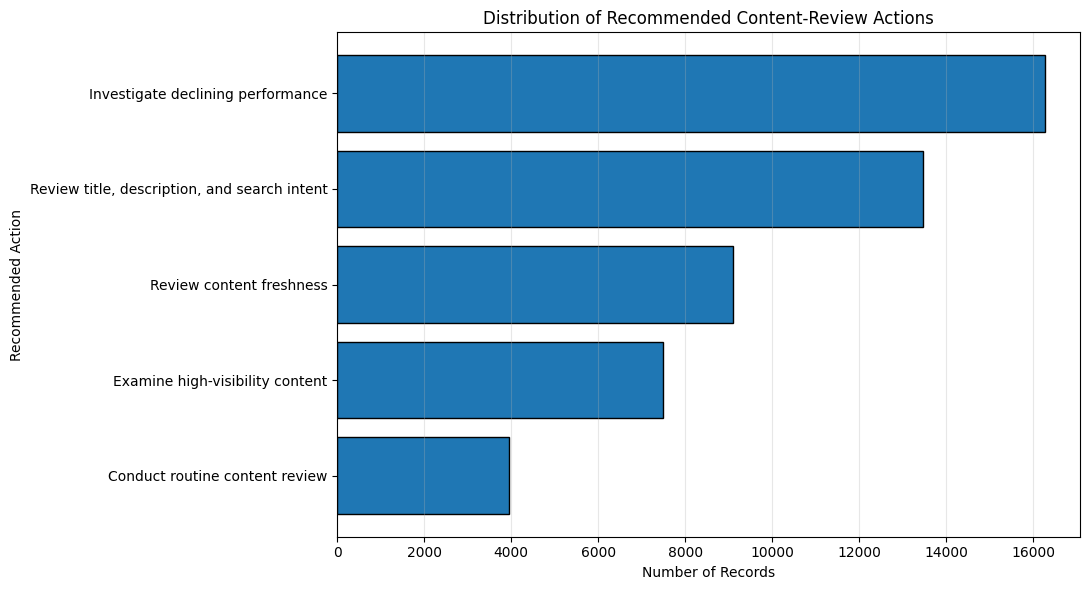

In [72]:
# SECTION 6 — Step 3: Recommendation summary

action_counts = (
    work_df["recommended_action"]
    .str.split("; ")
    .explode()
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="record_count")
)

print("Recommendation action summary:")
display(action_counts)

# Visualize the action distribution
plt.figure(figsize=(11, 6))

plt.barh(
    action_counts["recommended_action"],
    action_counts["record_count"],
    edgecolor="black"
)

plt.title("Distribution of Recommended Content-Review Actions")
plt.xlabel("Number of Records")
plt.ylabel("Recommended Action")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

In [73]:
# SECTION 6 — Step 4: Priority-group summary

priority_summary = (
    work_df.groupby(
        "priority_group",
        observed=False
    )
    .agg(
        record_count=("review_priority_score", "size"),
        average_score=("review_priority_score", "mean"),
        declining_share=("declining_signal", "mean"),
        low_ctr_share=("low_ctr_signal", "mean"),
        average_staleness=("staleness_score", "mean")
    )
    .round(3)
)

print("Priority-group recommendation summary:")
display(priority_summary)

Priority-group recommendation summary:


,record_count,average_score,declining_share,low_ctr_share,average_staleness
priority_group,,,,,
Low priority,10946,23.061,0.000,0.287,0.424
Moderate priority,7643,51.229,0.635,0.365,0.441
High priority,7701,71.167,1.000,0.497,0.531
Very high priority,3710,88.395,1.000,1.000,0.783


In [74]:
# SECTION 6 — Step 5: Export the action playbook

output_file = "ranked_content_recommendations.csv"

ranked_playbook[playbook_columns].to_csv(
    output_file,
    index=False
)

print("Export completed:", output_file)

from google.colab import files
files.download(output_file)

Export completed: ranked_content_recommendations.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Recommendations and Action Playbook

The review-priority ranking can be used to organize content-review activities into manageable groups.

**Very-high-priority records:** Consider these records for earlier human review. Investigate declining performance, relative CTR, and content freshness before deciding whether an update is appropriate.

**High-priority records:** Examine records with multiple review signals. Determine whether changes to content accuracy, relevance, structure, or presentation are justified by the available evidence.

**Moderate-priority records:** Schedule these records for routine review and monitor their performance for meaningful changes.

**Low-priority records:** Continue normal monitoring and consider reviewing these records when new performance signals or business requirements emerge.

The action-playbook recommendations are generated from observable dataset features. They should be treated as investigation suggestions rather than automatic instructions to modify content.

### Practical Implementation

A content team could use the ranked output as a review queue. Reviewers can inspect the relevant content, confirm whether the signals indicate a genuine issue, and document the decision to update, monitor, or leave the content unchanged.

The effectiveness of this workflow should be evaluated using subsequent performance measurements and independently defined review outcomes.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section collects the visualizations, summary tables, and ranked recommendations generated during the analysis.

The artifacts provide a reproducible record of the project's findings and are intended for inclusion in the capstone paper and presentation through the deployed page.

The exported outputs include review-priority distributions, ranking comparisons, priority-group summaries, and a ranked content-review action playbook. Identifying information is excluded from public-facing outputs.


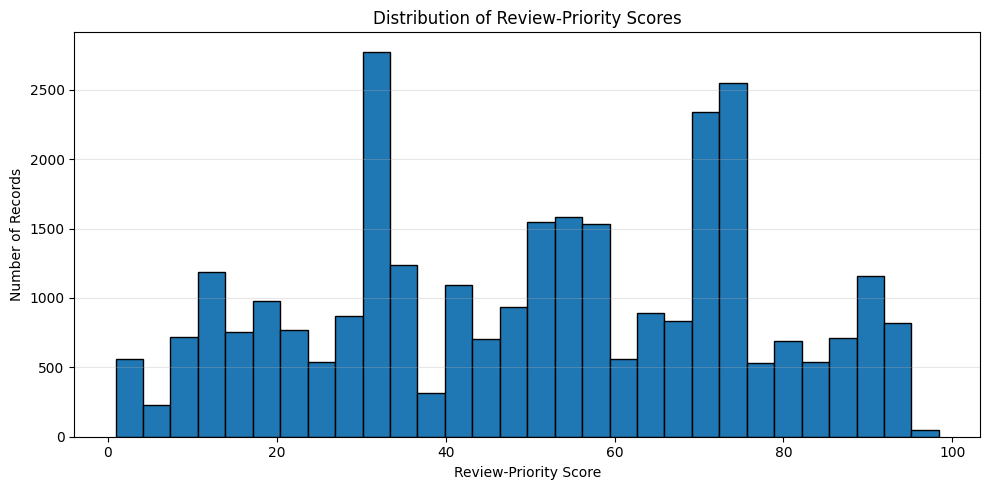

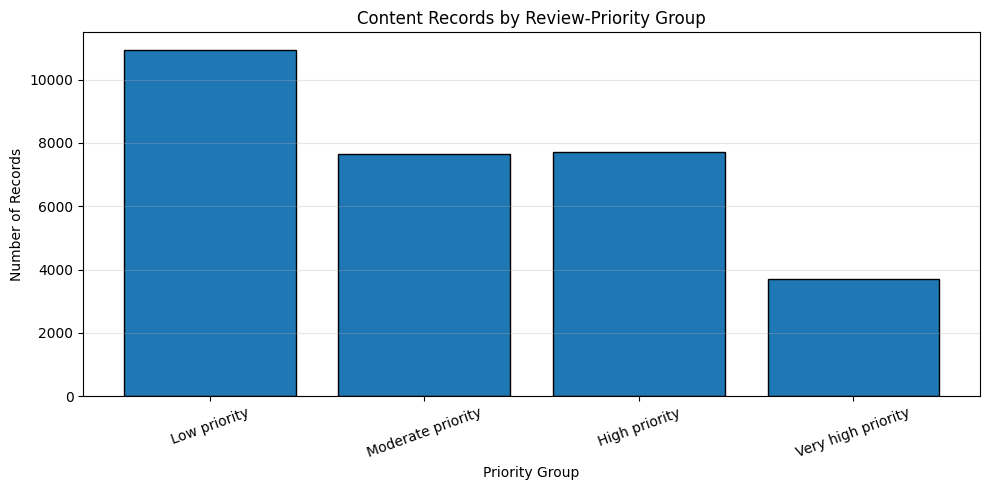

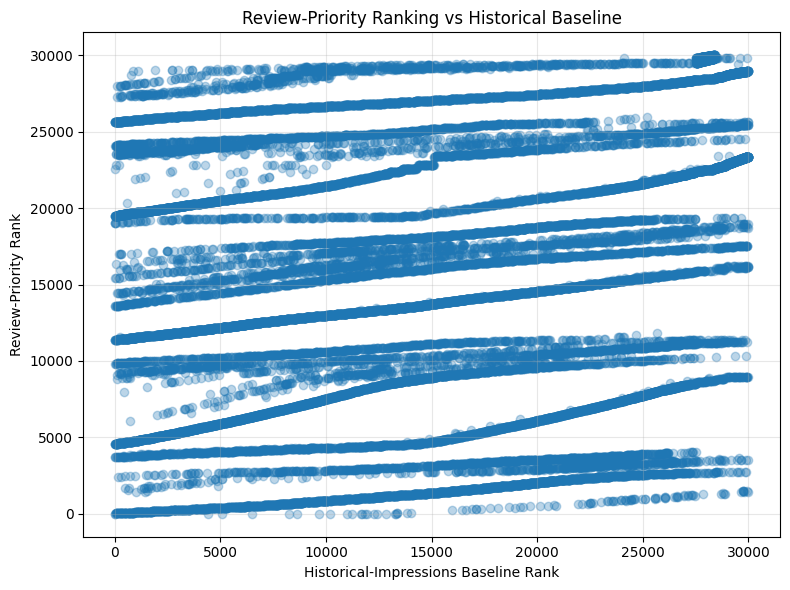

Artifact generation completed.

Figures:
 - figure_01_score_distribution.png
 - figure_02_priority_groups.png
 - figure_03_ranking_comparison.png

Tables:
 - priority_group_summary.csv
 - top_100_recommendations.csv
 - review_priority_score_summary.csv

Statistics:
 - ranking_comparison.json


In [75]:
# SECTION 7 — Step 1: Generate and export project artifacts

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create output folders
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --------------------------------------------------
# 1. Review-priority score distribution
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    work_df["review_priority_score"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Review-Priority Scores")
plt.xlabel("Review-Priority Score")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "work/figures/figure_01_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# --------------------------------------------------
# 2. Priority-group distribution
# --------------------------------------------------

priority_order = [
    "Low priority",
    "Moderate priority",
    "High priority",
    "Very high priority"
]

group_counts = (
    work_df["priority_group"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
)

plt.figure(figsize=(10, 5))

plt.bar(
    group_counts.index,
    group_counts.values,
    edgecolor="black"
)

plt.title("Content Records by Review-Priority Group")
plt.xlabel("Priority Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "work/figures/figure_02_priority_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# --------------------------------------------------
# 3. Compare review-priority and baseline rankings
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    work_df["baseline_rank"],
    work_df["priority_rank"],
    alpha=0.3
)

plt.title("Review-Priority Ranking vs Historical Baseline")
plt.xlabel("Historical-Impressions Baseline Rank")
plt.ylabel("Review-Priority Rank")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "work/figures/figure_03_ranking_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# --------------------------------------------------
# 4. Export priority-group summary
# --------------------------------------------------

priority_summary = (
    work_df.groupby("priority_group", observed=False)
    .agg(
        record_count=("review_priority_score", "size"),
        average_score=("review_priority_score", "mean"),
        average_impressions=("impressions_90d", "mean"),
        average_staleness=("staleness_score", "mean"),
        declining_share=("declining_signal", "mean"),
        low_ctr_share=("low_ctr_signal", "mean")
    )
    .round(3)
    .reset_index()
)

priority_summary.to_csv(
    "work/outputs/priority_group_summary.csv",
    index=False
)


# --------------------------------------------------
# 5. Export top 100 ranked recommendations
# --------------------------------------------------

ranked_playbook = work_df.sort_values(
    "review_priority_score",
    ascending=False
).copy()

ranked_playbook["anonymous_record_number"] = range(
    1, len(ranked_playbook) + 1
)

public_columns = [
    "anonymous_record_number",
    "priority_group",
    "content_type",
    "main_intent",
    "trend_direction",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "review_priority_score",
    "recommended_action",
    "recommendation_reason"
]

ranked_playbook[public_columns].head(100).to_csv(
    "work/outputs/top_100_recommendations.csv",
    index=False
)


# --------------------------------------------------
# 6. Export score summary
# --------------------------------------------------

score_summary = (
    work_df["review_priority_score"]
    .describe()
    .round(3)
    .to_frame(name="review_priority_score")
)

score_summary.to_csv(
    "work/outputs/review_priority_score_summary.csv"
)


# --------------------------------------------------
# 7. Export ranking comparison statistics
# --------------------------------------------------

top_priority = set(
    work_df.nsmallest(100, "priority_rank").index
)

top_baseline = set(
    work_df.nsmallest(100, "baseline_rank").index
)

overlap = len(top_priority & top_baseline)

spearman_corr = work_df["priority_rank"].corr(
    work_df["baseline_rank"],
    method="spearman"
)

ranking_summary = {
    "number_of_records": int(len(work_df)),
    "top_100_overlap_count": int(overlap),
    "top_100_overlap_percentage": float(overlap),
    "spearman_rank_correlation": float(spearman_corr)
}

with open(
    "work/outputs/ranking_comparison.json",
    "w"
) as f:
    json.dump(ranking_summary, f, indent=4)


# --------------------------------------------------
# 8. Export artifact manifest
# --------------------------------------------------

artifact_manifest = {
    "figures": [
        "figure_01_score_distribution.png",
        "figure_02_priority_groups.png",
        "figure_03_ranking_comparison.png"
    ],
    "tables": [
        "priority_group_summary.csv",
        "top_100_recommendations.csv",
        "review_priority_score_summary.csv"
    ],
    "statistics": [
        "ranking_comparison.json"
    ]
}

with open(
    "work/outputs/artifact_manifest.json",
    "w"
) as f:
    json.dump(artifact_manifest, f, indent=4)

print("Artifact generation completed.")

print("\nFigures:")
for name in artifact_manifest["figures"]:
    print(" -", name)

print("\nTables:")
for name in artifact_manifest["tables"]:
    print(" -", name)

print("\nStatistics:")
for name in artifact_manifest["statistics"]:
    print(" -", name)

In [76]:
# SECTION 7 — Step 2: Package all artifacts

import shutil
import os

shutil.make_archive(
    "capstone_artifacts",
    "zip",
    root_dir="work"
)

print("ZIP file created: capstone_artifacts.zip")

from google.colab import files
files.download("capstone_artifacts.zip")

ZIP file created: capstone_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Artifact Documentation

The project artifacts include three principal visualizations: the distribution of review-priority scores, the distribution of records across priority groups, and a comparison of the review-priority ranking with the historical-impressions baseline.

The exported tables provide descriptive statistics, priority-group characteristics, and the top 100 ranked recommendations. A machine-readable ranking summary and artifact manifest are also provided to support reproducibility and integration with the deployed page.

Public-facing artifacts use anonymous record numbers and exclude direct content and client identifiers.

The visualizations and tables describe the dataset and the behavior of the proposed scoring methodology. They do not independently establish that recommended content updates will improve future performance.


In [77]:
# SECTION 7 — Step 3: Verify exported artifacts

for folder in ["work/figures", "work/outputs"]:

    print(f"\nFiles in {folder}:")

    for filename in sorted(os.listdir(folder)):
        filepath = os.path.join(folder, filename)

        if os.path.isfile(filepath):
            print(
                f"{filename} — "
                f"{os.path.getsize(filepath):,} bytes"
            )


Files in work/figures:
figure_01_score_distribution.png — 91,007 bytes
figure_02_priority_groups.png — 141,858 bytes
figure_03_ranking_comparison.png — 1,282,986 bytes

Files in work/outputs:
artifact_manifest.json — 359 bytes
priority_group_summary.csv — 323 bytes
ranking_comparison.json — 159 bytes
review_priority_score_summary.csv — 114 bytes
top_100_recommendations.csv — 35,355 bytes


## 9. Acknowledgments & Data Credit

I acknowledge FlyRank for providing the opportunity to work on this machine-learning capstone project and for the anonymized dataset used in this analysis.

The project was developed to explore transparent, data-driven approaches to content-review prioritization. The findings and recommendations are based on the available dataset and should be interpreted within the documented methodological limitations.

Data and project credit: https://flyrank.ai


## ML-12. Project Communication & Demo

### 1. Five-Minute Demo Outline

| Time      | Demonstration                                                                                  |
| --------- | ---------------------------------------------------------------------------------------------- |
| 0:00–0:30 | Introduce the research question and the content-review problem.                                |
| 0:30–1:15 | Explain the anonymized dataset, its dimensions, and the important features.                    |
| 1:15–2:15 | Demonstrate the review-priority scoring methodology and its four components.                   |
| 2:15–3:15 | Present the results, priority groups, ranking comparison, and sensitivity analysis.            |
| 3:15–4:15 | Show the ranked recommendations and explain how a reviewer could use the action playbook.      |
| 4:15–5:00 | Discuss limitations, explain what the analysis cannot establish, and summarize the next steps. |

### 2. Social-Post Version

Completed my machine-learning capstone project exploring data-driven content-review prioritization.

Using an anonymized dataset of 30,000 records, I developed a transparent heuristic scoring approach based on declining performance, content freshness, relative click-through rates, and historical visibility.

The project includes ranking comparisons, sensitivity analysis, visualizations, and an actionable content-review playbook. The work focuses on interpretable decision support, with clear limitations around predictive accuracy and causal conclusions.

### 3. Employer-Facing Summary

Developed a Python and Pandas-based content-review prioritization pipeline using an anonymized dataset of 30,000 records. Implemented a transparent weighted scoring methodology, compared its ranking with a historical-impressions baseline, and evaluated ranking stability under alternative scoring weights. Generated ranked recommendations, descriptive visualizations, and reproducible project artifacts while documenting methodological limitations and the need for independent outcome validation.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
